In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import illustris_python as il
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
import networkx as nx
import matplotlib as mpl
from mpl_toolkits.axes_grid1 import make_axes_locatable
from astropy import units as u
import time
import scipy.linalg

In [4]:
basePath = '../data'

In [121]:
fields = ['SubhaloFlag', 'SubhaloGrNr', 'SubhaloMass','SubhaloMassType', 'SubhaloParent', 'SubhaloPos', 'SubhaloLenType', 
          'SubhaloStarMetallicity', 'SubhaloSFR', 'SubhaloGasMetallicity', 'SubhaloGasMetalFractions', 'SubhaloGrNr']
subhalos = il.groupcat.loadSubhalos(basePath,99,fields=fields)

In [122]:
GroupFirstSub = il.groupcat.loadHalos(basePath,99,fields=['GroupFirstSub'])

In [123]:
# centrals_sum = 0
centrals_flag = np.zeros(len(subhalos['SubhaloGrNr']))

for i, subhalo_group in enumerate(subhalos['SubhaloGrNr']):
    if GroupFirstSub[subhalo_group] == i:
        centrals_flag[i] = 1
        # print(i, subhalo_group)
print(sum(centrals_flag) / len(centrals_flag))

0.7848410886594127


In [124]:
subhalos['centrals_flag'] = centrals_flag

In [125]:
subhalos

{'count': 4371211,
 'SubhaloFlag': array([ True,  True,  True, ...,  True,  True,  True]),
 'SubhaloGrNr': array([      0,       0,       0, ..., 6291318, 6291321, 6291342],
       dtype=int32),
 'SubhaloMass': array([2.7477936e+04, 3.6666228e+03, 7.7345551e+02, ..., 1.5167229e-02,
        1.4661655e-02, 1.4156080e-02], dtype=float32),
 'SubhaloMassType': array([[3.9005981e+03, 2.3325619e+04, 0.0000000e+00, 0.0000000e+00,
         2.5101631e+02, 7.0181096e-01],
        [4.4455853e+02, 3.1840862e+03, 0.0000000e+00, 0.0000000e+00,
         3.7852551e+01, 1.2556633e-01],
        [1.2611633e+01, 7.1818396e+02, 0.0000000e+00, 0.0000000e+00,
         4.2482437e+01, 1.7748705e-01],
        ...,
        [0.0000000e+00, 1.5167229e-02, 0.0000000e+00, 0.0000000e+00,
         0.0000000e+00, 0.0000000e+00],
        [0.0000000e+00, 1.4661655e-02, 0.0000000e+00, 0.0000000e+00,
         0.0000000e+00, 0.0000000e+00],
        [0.0000000e+00, 1.4156080e-02, 0.0000000e+00, 0.0000000e+00,
         0.00000

In [126]:
subhalos.keys()

dict_keys(['count', 'SubhaloFlag', 'SubhaloGrNr', 'SubhaloMass', 'SubhaloMassType', 'SubhaloParent', 'SubhaloPos', 'SubhaloLenType', 'SubhaloStarMetallicity', 'SubhaloSFR', 'SubhaloGasMetallicity', 'SubhaloGasMetalFractions', 'centrals_flag'])

In [127]:
for i in range(3):
    subhalos['SubhaloPos'][:,i] = ((subhalos['SubhaloPos'][:,i]) * u.kpc).to(u.Mpc)

In [128]:
def impose_cut(subhalos, boolean_array):
    for key in subhalos.keys():
        if key != 'count':
            subhalos[key] = subhalos[key][boolean_array]
        else:
            subhalos[key] = sum(boolean_array)
    return subhalos

In [129]:
# subhalos = impose_cut(subhalos, subhalos['SubhaloMass']*1e10 >=1e9) # subhalo mass > 1e9 Msun
subhalos = impose_cut(subhalos, subhalos['SubhaloMassType'][:,4]*1e10 >=1e9) # subhalo mass > 1e9 Msun
subhalos = impose_cut(subhalos, subhalos['SubhaloFlag'] > 0) # is actually a subhalo
subhalos = impose_cut(subhalos, subhalos['SubhaloLenType'][:,4] > 100) # more than 100 star particles

In [130]:
sum(subhalos['centrals_flag']) / len(subhalos['centrals_flag'])

0.5832150360570099

In [131]:
subhalos['SubhaloPos'].shape

(17611, 3)

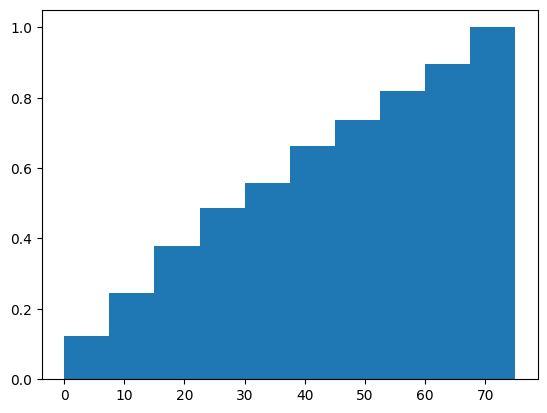

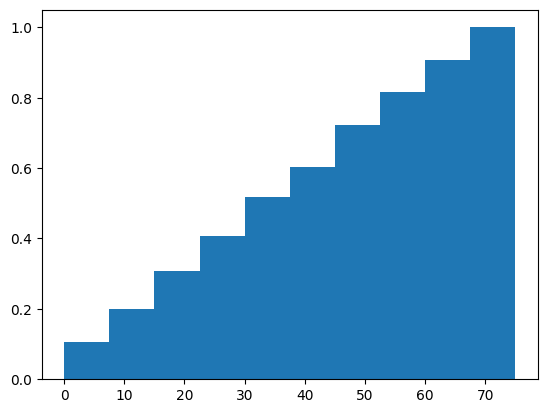

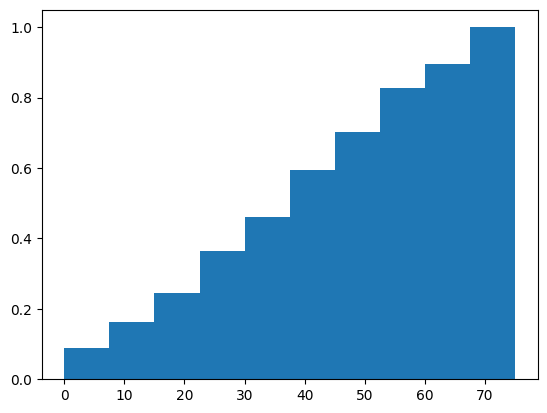

In [132]:
for i in range(3):
    plt.hist(subhalos['SubhaloPos'][:,i], cumulative=True, density=True)
    plt.show()

In [133]:
limit = 50
for i in range(3):
    subhalos = impose_cut(subhalos, subhalos['SubhaloPos'][:,i] < limit)

In [134]:
subhalos['count']

5745

In [135]:
subhalos['SubhaloPos']

array([[ 0.8490915 , 26.326998  , 18.306934  ],
       [ 0.10647334, 24.633324  , 16.900553  ],
       [ 0.8531124 , 26.72575   , 17.510681  ],
       ...,
       [12.101596  ,  0.7713217 ,  8.467401  ],
       [ 2.0424943 , 25.050951  , 18.758776  ],
       [12.748418  , 49.63988   , 47.6435    ]], dtype=float32)

In [136]:
subhalos['SubhaloPos'][:,0]

array([ 0.8490915 ,  0.10647334,  0.8531124 , ..., 12.101596  ,
        2.0424943 , 12.748418  ], dtype=float32)

In [140]:
subhalos['centrals_flag']

array([1., 0., 0., ..., 1., 1., 1.])

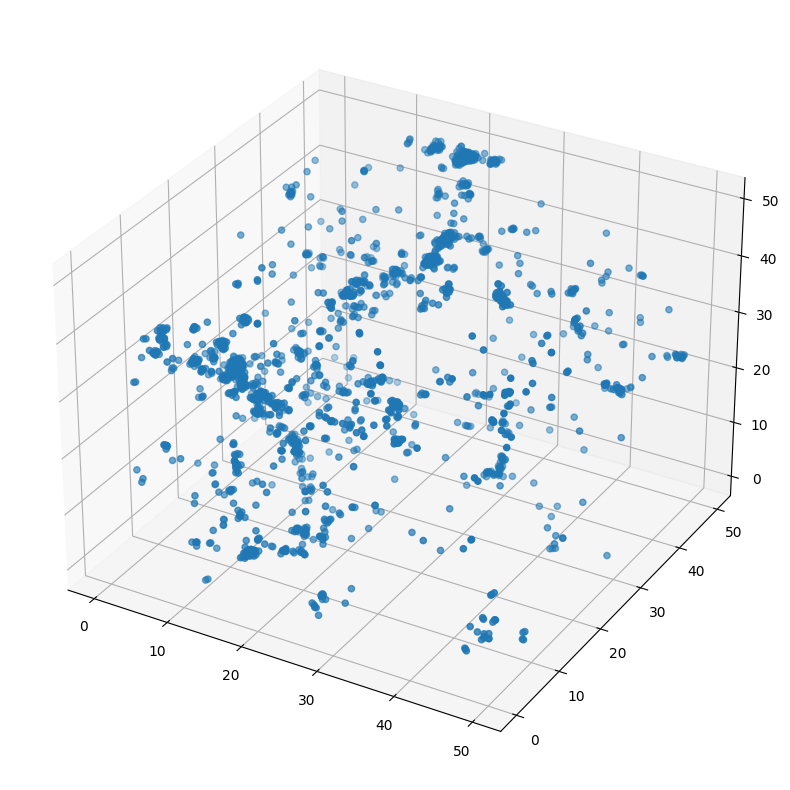

In [150]:
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(projection='3d')
# ax.scatter(subhalos['SubhaloPos'][:,0], subhalos['SubhaloPos'][:,1], subhalos['SubhaloPos'][:,2])
# ax.scatter(subhalos['SubhaloPos'][subhalos['centrals_flag'] == 1][:,0], subhalos['SubhaloPos'][subhalos['centrals_flag'] == 1][:,1], subhalos['SubhaloPos'][subhalos['centrals_flag'] == 1][:,2])
ax.scatter(subhalos['SubhaloPos'][subhalos['centrals_flag'] == 0][:,0], subhalos['SubhaloPos'][subhalos['centrals_flag'] == 0][:,1], subhalos['SubhaloPos'][subhalos['centrals_flag'] == 0][:,2])

plt.show()

In [143]:
def adjust_distances(dist, boxsize):
    if dist > boxsize / 2:
        dist = boxsize - dist
    elif dist <= -boxsize / 2:
        dist = boxsize + dist
    return dist

In [144]:
# Periodic boundary conditions (box size 50)
def periodic_distance_matrix(xs, ys, zs, boxsize):
    points = np.vstack((xs, ys, zs)).T
    num_points = points.shape[0]
    dist_matrix = np.zeros((num_points, num_points))
    for i in range(num_points):
        delta = points - points[i]
        delta = delta - boxsize * np.round(delta / boxsize)
        dist_matrix[i] = np.sqrt(np.sum(delta**2, axis=1))
        # dx = delta[:,0]
        # dy = delta[:,1]
        # dz = delta[:,2]

        # new_dx = np.array([adjust_distances(d, boxsize) for d in dx])
        # new_dy = np.array([adjust_distances(d, boxsize) for d in dy])
        # new_dz = np.array([adjust_distances(d, boxsize) for d in dz])
        # dist_matrix[i] = np.sqrt(new_dx**2 + new_dy**2 + new_dz**2)
    return dist_matrix

boxsize = 50
distance_matrix = periodic_distance_matrix(subhalos['SubhaloPos'][:,0], subhalos['SubhaloPos'][:,1], subhalos['SubhaloPos'][:,2], boxsize)

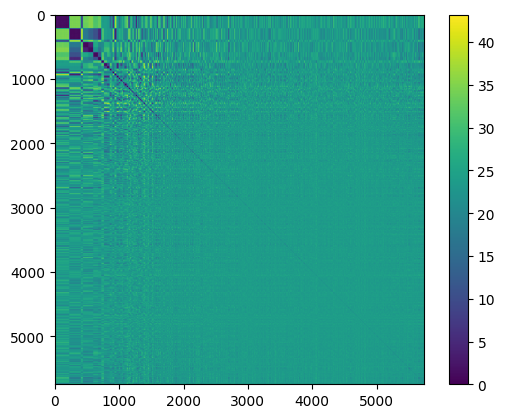

In [145]:
plt.imshow(distance_matrix)
plt.colorbar()
plt.show()

In [146]:
threshold = 5  # Set your desired threshold value

nearest_neighbor_matrix = np.where(distance_matrix < threshold, distance_matrix, 0)

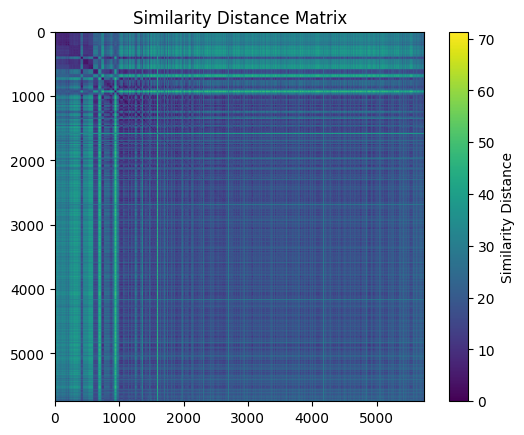

In [147]:
similarity_distances = euclidean_distances(np.sort(nearest_neighbor_matrix, axis=1))
plt.imshow(similarity_distances)
plt.colorbar(label='Similarity Distance')
plt.title('Similarity Distance Matrix')
plt.show()

/Users/anasofiauzsoy/anaconda/envs/py310_clone/lib/python3.10/site-packages/matplotlib/cbook/__init__.py:1335: ComplexWarning:

Casting complex values to real discards the imaginary part



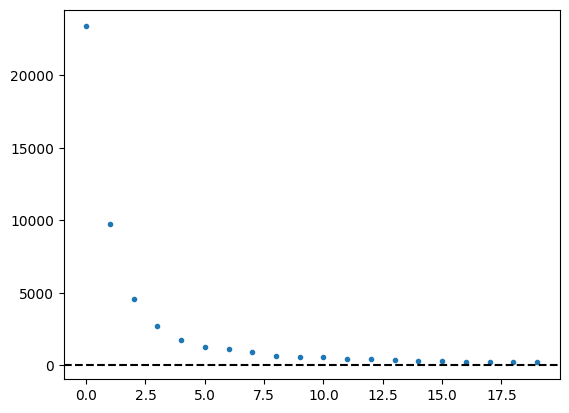

In [148]:
# Isomap embedding
D = similarity_distances

num_points = D.shape[0]
C = np.eye(num_points) - (1 / num_points)*np.ones_like(D)
B = -0.5 * np.matmul(C, np.matmul(D, C))
evals, evecs = np.linalg.eig(B)
plt.plot(evals[:20], '.')
plt.axhline(0, color='k', linestyle='--')

In [149]:
# Use only leading positive eigenvalues
# num_positive = np.minimum(np.where(evals < 0)[0][0] - 1, 10)
num_positive = 10

print(np.sum(num_positive))
num_to_keep = max(2, np.sum(num_positive))
print(f"Keeping {num_to_keep} dimensions")
X = evecs[:, :num_to_keep] * np.sqrt(evals[:num_to_keep])

10
Keeping 10 dimensions


Explained variance ratio: [0.49991215 0.20880439 0.0981628 ]


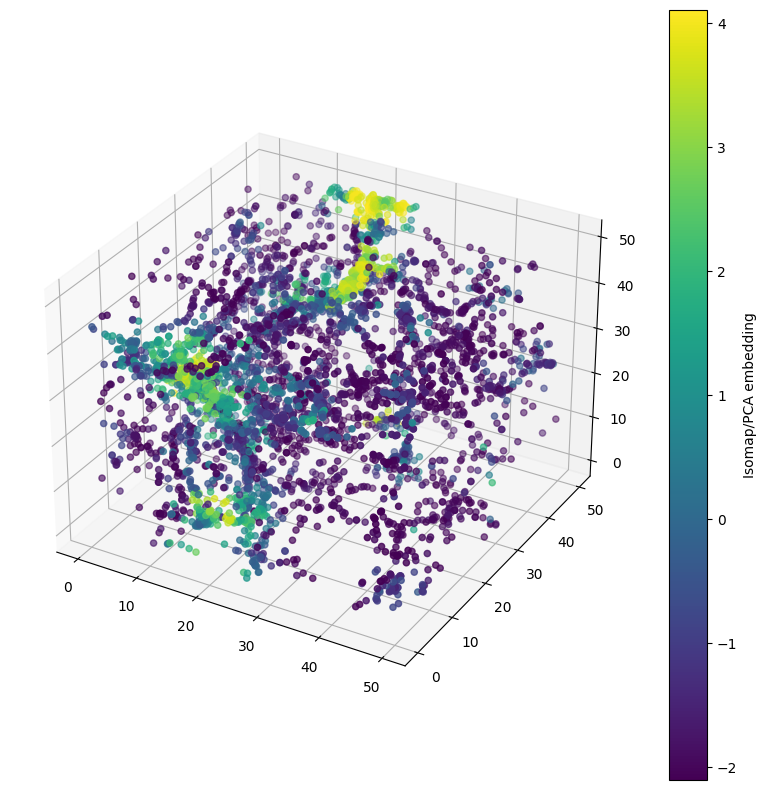

In [56]:
# PCA on Isomap embedding
pca = PCA(n_components=3)
embedding = pca.fit_transform(np.real(X))
# pca.fit(np.real(X.T))

print("Explained variance ratio:", pca.explained_variance_ratio_)

# Visualize embedding
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(projection='3d')
p = ax.scatter(subhalos['SubhaloPos'][:,0], subhalos['SubhaloPos'][:,1], subhalos['SubhaloPos'][:,2], c=embedding[:,0])
# p = ax.scatter(xs, ys, zs, c=pca.components_[0])

cbar = fig.colorbar(p, ax=ax)
cbar.set_label("Isomap/PCA embedding")
plt.show()

In [58]:
import plotly.express as px
fig = px.scatter_3d(x=subhalos['SubhaloPos'][:,0], y=subhalos['SubhaloPos'][:,1], z=subhalos['SubhaloPos'][:,2], color=embedding[:,0])
fig.update_traces(marker=dict(size=4))

fig.update_layout(margin=dict(l=0, r=0, b=0, t=0))
from plotly.offline import plot
plot(fig, filename='galaxies.html', auto_open=True)


'galaxies.html'

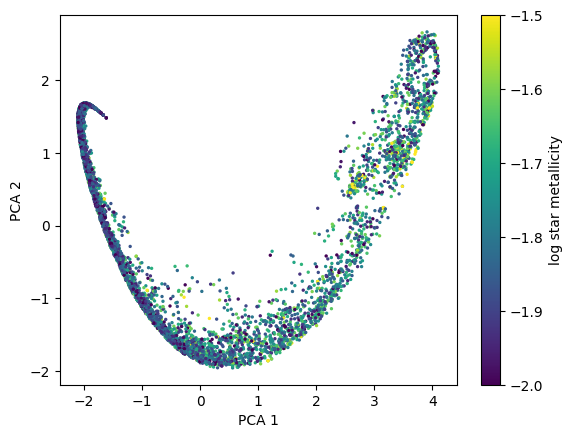

In [70]:
plt.scatter(embedding[:,0], embedding[:,1], c = np.log10(subhalos['SubhaloStarMetallicity']), s=2, vmax=-1.5, vmin=-2)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.colorbar(label="log star metallicity")
plt.show()

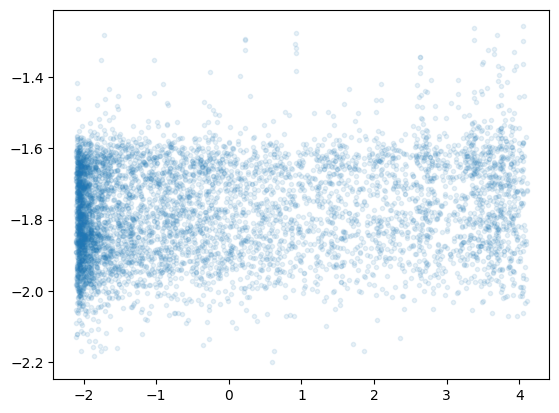

In [75]:
plt.plot(embedding[:,0], np.log10(subhalos['SubhaloStarMetallicity']), '.', alpha=0.1)


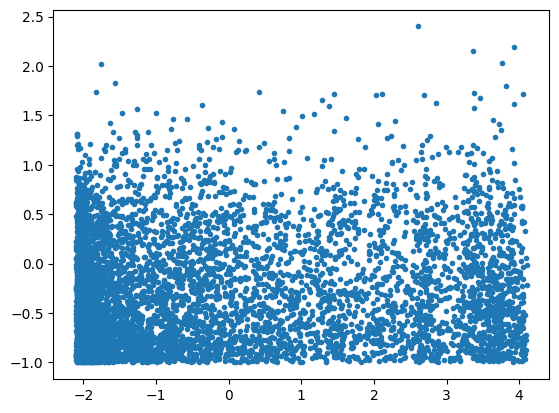

In [66]:
plt.plot(embedding[:,0], np.log10(subhalos['SubhaloMassType'][:,4]), '.')

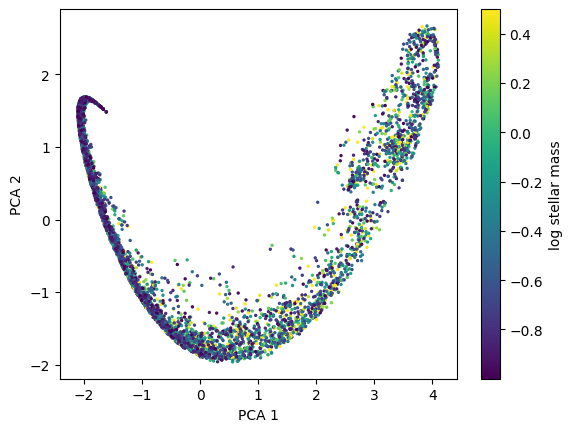

In [64]:
plt.scatter(embedding[:,0], embedding[:,1], c =np.log10(subhalos['SubhaloMassType'][:,4]),s=2, vmax=0.5)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.colorbar(label="log stellar mass")
plt.show()

--------------------------------------------------

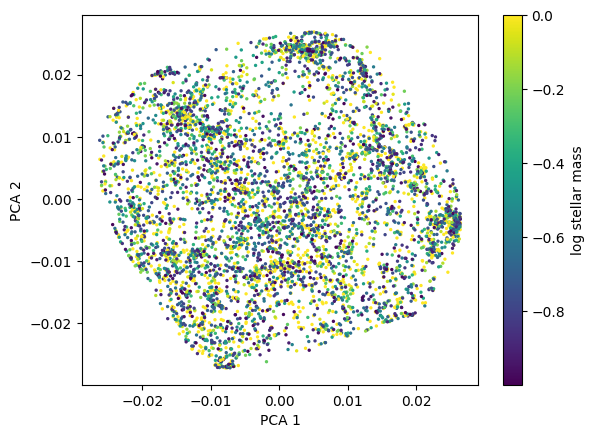

In [100]:
plt.scatter(pca.components_[0], pca.components_[1], c = np.log10(subhalos['SubhaloMassType'][:,4]),s=2, vmax=0)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.colorbar(label="log stellar mass")
plt.show()

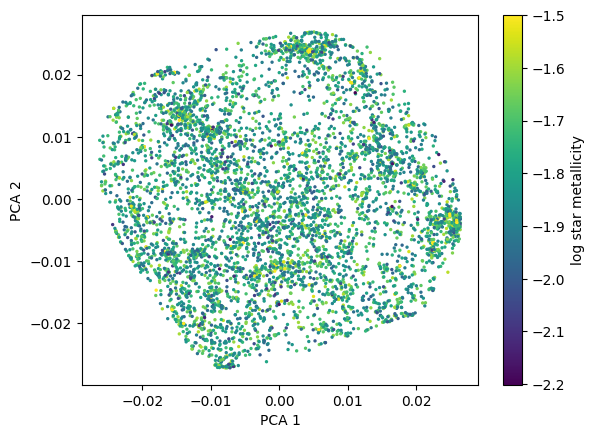

In [101]:
plt.scatter(pca.components_[0], pca.components_[1], c = np.log10(subhalos['SubhaloStarMetallicity']),s=2, vmax=-1.5)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.colorbar(label="log star metallicity")
plt.show()

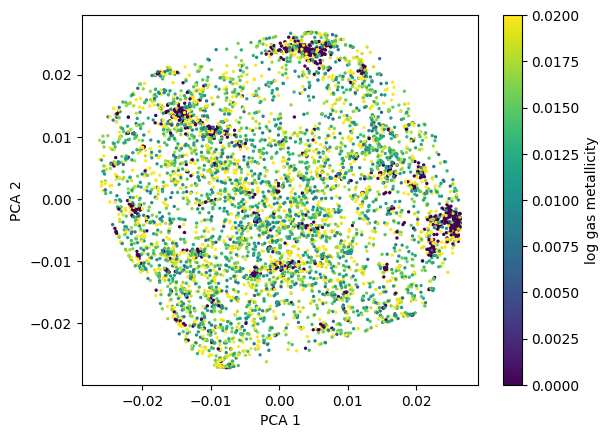

In [116]:
f = plt.figure()
plt.scatter(pca.components_[0], pca.components_[1], c = subhalos['SubhaloGasMetallicity'],s=2, vmax=0.02)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.colorbar(label="log gas metallicity")
plt.show()
f.savefig("gas_metallicity_embedding.pdf")

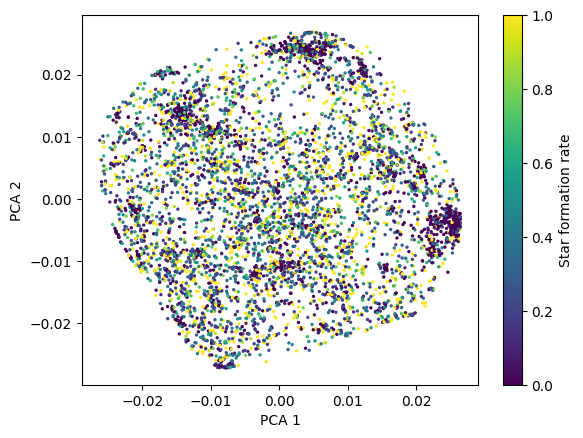

In [114]:
f = plt.figure()
plt.scatter(pca.components_[0], pca.components_[1], c = subhalos['SubhaloSFR'],s=2, vmax=1)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.colorbar(label="Star formation rate")
plt.show()
f.savefig("SFR_embedding.pdf")

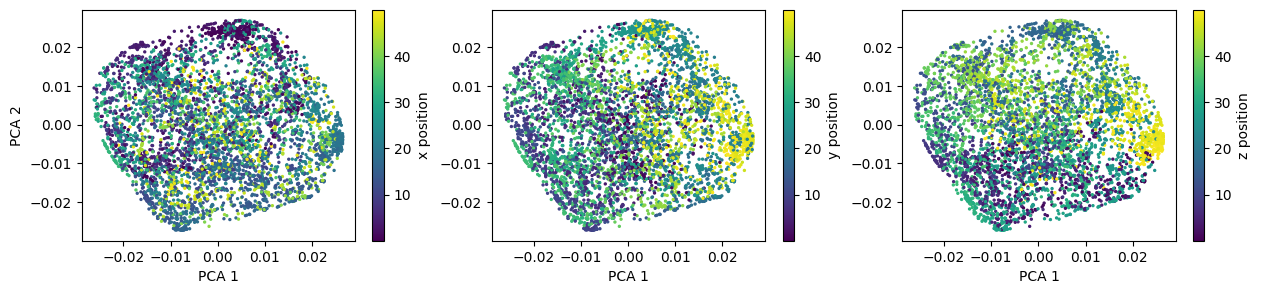

In [104]:
l = ["x", "y", "z"]
fig, ax = plt.subplots(1, 3, figsize=(15,3))
for i in range(3):
    l2 = ax[i].scatter(pca.components_[0], pca.components_[1], c = subhalos['SubhaloPos'][:,i],s=2)
    ax[i].set_xlabel("PCA 1")
    ax[0].set_ylabel("PCA 2")
    plt.colorbar(l2 ,label=l[i]+" position", ax=ax[i])
    # plt.show()

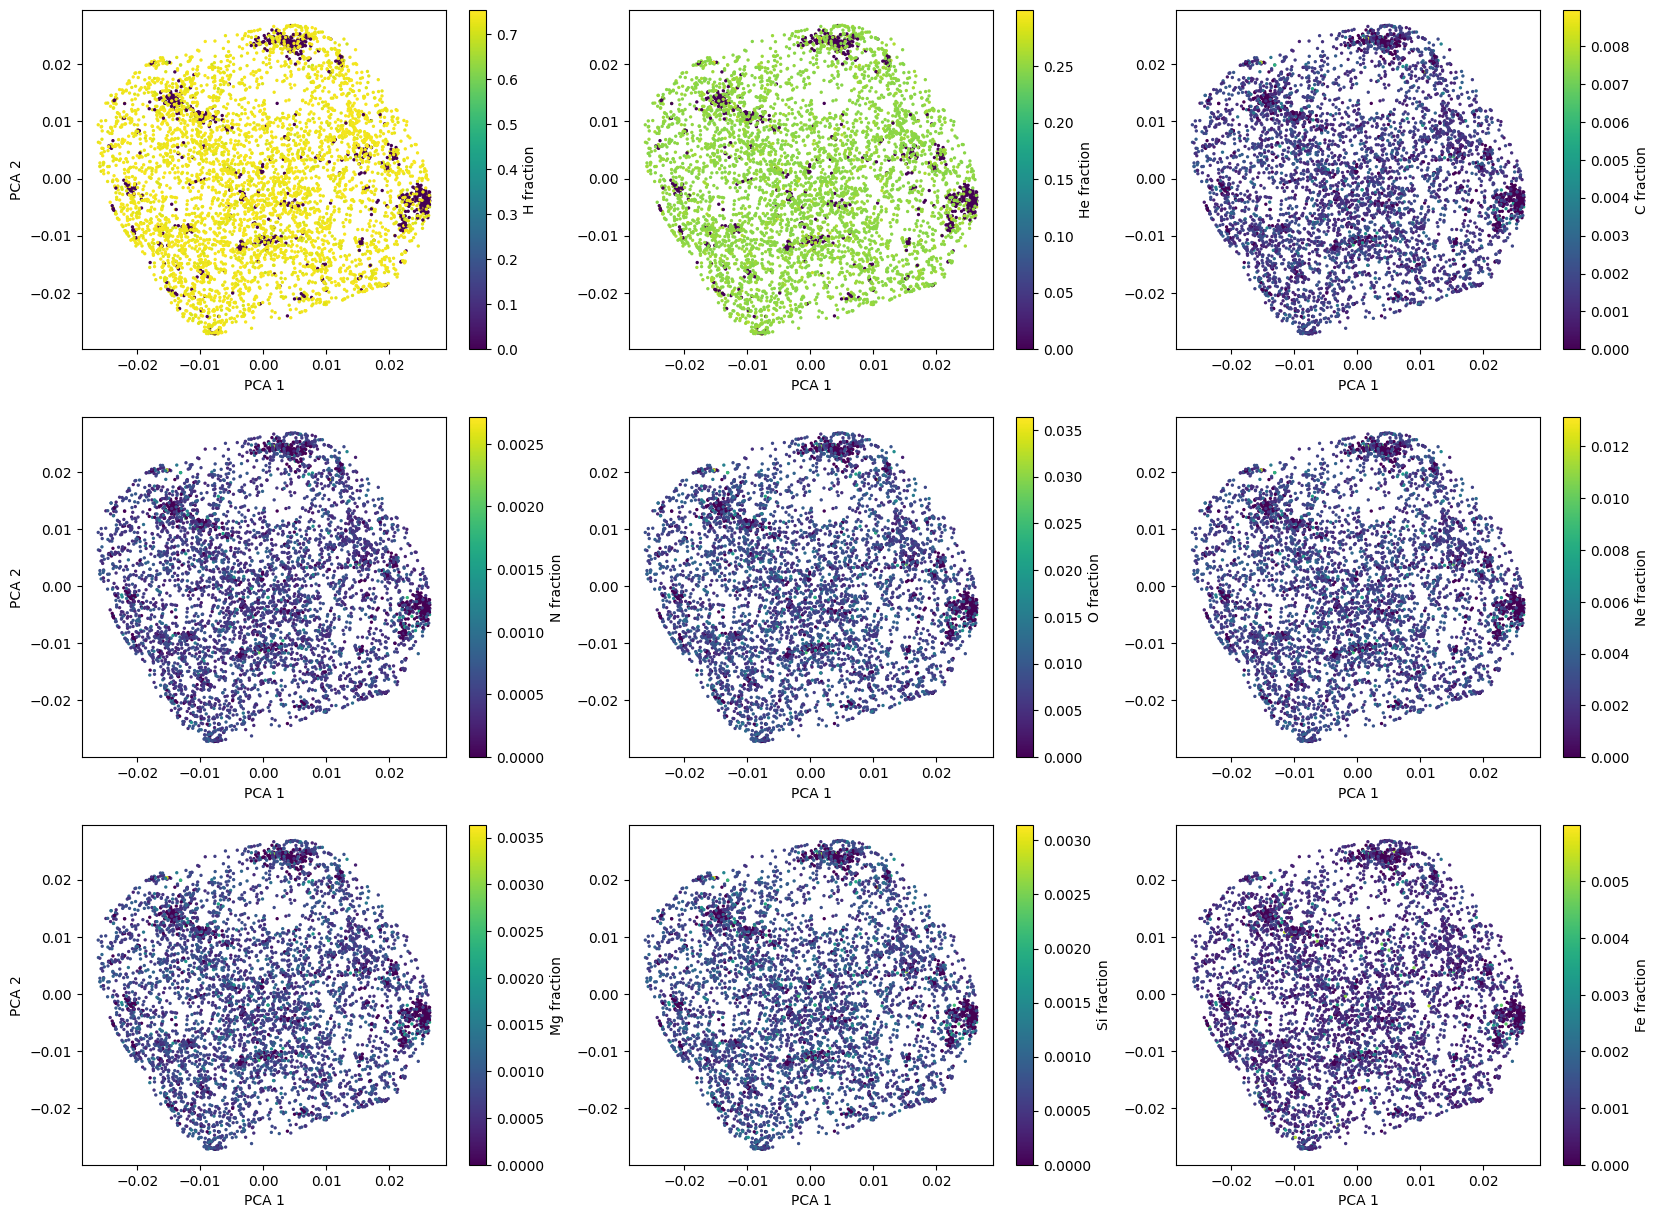

In [105]:
gases = ['H', 'He', 'C', 'N', 'O', 'Ne', 'Mg', 'Si', 'Fe', 'total']
fig, ax = plt.subplots(3, 3, figsize=(20,15))
index = 0
for i in range(3):
    for j in range(3):
        l2 = ax[i][j].scatter(pca.components_[0], pca.components_[1], c =subhalos['SubhaloGasMetalFractions'][:,index],s=2)
        ax[i][j].set_xlabel("PCA 1")
        ax[i][0].set_ylabel("PCA 2")
        plt.colorbar(l2 ,label=gases[index]+" fraction", ax=ax[i][j])
        index += 1

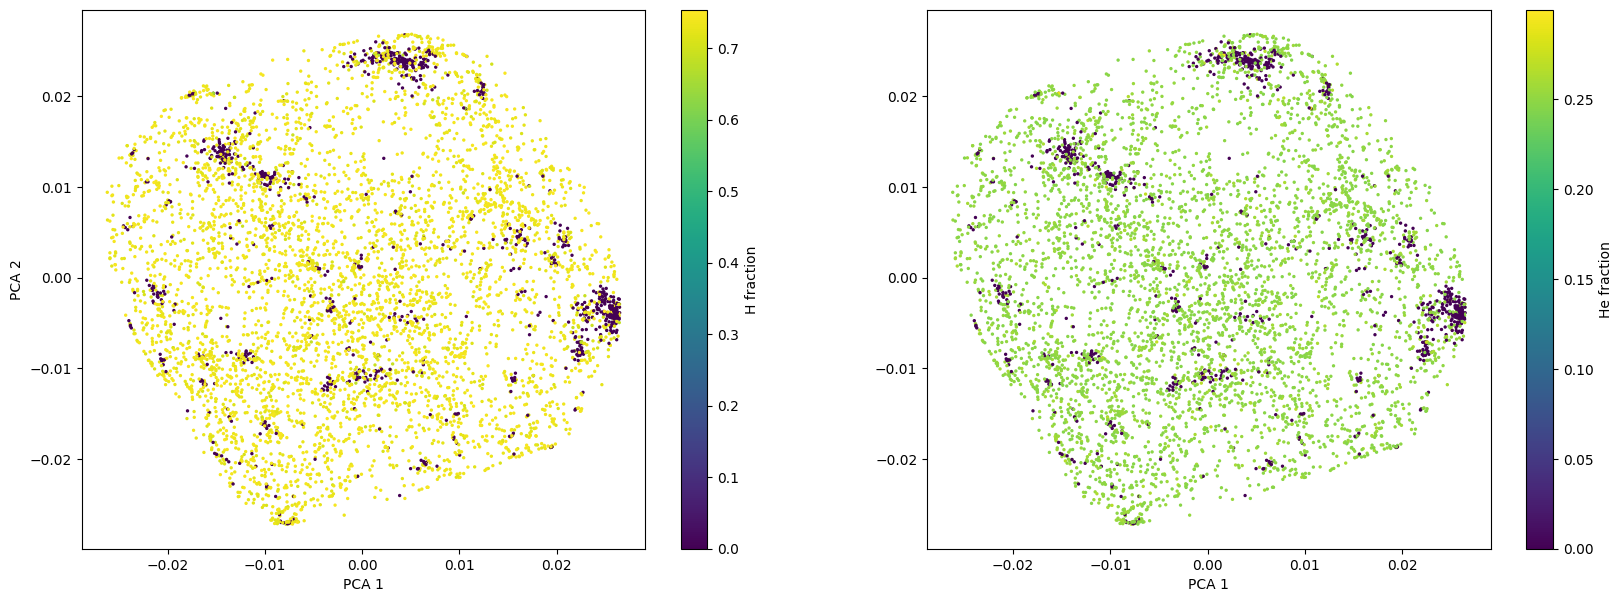

In [106]:
gases = ['H', 'He', 'C', 'N', 'O', 'Ne', 'Mg', 'Si', 'Fe', 'total']
fig, ax = plt.subplots(1, 2, figsize=(20,7))
index = 0
for i in range(2):
    l2 = ax[i].scatter(pca.components_[0], pca.components_[1], c =subhalos['SubhaloGasMetalFractions'][:,index],s=2)
    ax[i].set_xlabel("PCA 1")
    ax[0].set_ylabel("PCA 2")
    plt.colorbar(l2 ,label=gases[index]+" fraction", ax=ax[i])
    index += 1

In [107]:
fig.savefig("H_He_embedding.pdf")

limit connections to be within 150 MPc (this is where distance metrics don't matter)

In [117]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.offline import plot
# df = px.data.iris()
fig = px.scatter_3d(x=subhalos['SubhaloPos'][:,0], y=subhalos['SubhaloPos'][:,1], z=subhalos['SubhaloPos'][:,2],
                    color=pca.components_[0])
fig.update_layout(margin=dict(l=0, r=0, b=0, t=0))
plot(fig, filename='galaxies.html', auto_open=True)


'galaxies.html'

In [119]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.offline import plot
# df = px.data.iris()
fig = px.scatter_3d(x=subhalos['SubhaloPos'][:,0], y=subhalos['SubhaloPos'][:,1], z=subhalos['SubhaloPos'][:,2],
                    color=pca.components_[1])
fig.update_layout(margin=dict(l=0, r=0, b=0, t=0))
plot(fig, filename='galaxies2.html', auto_open=True)

'galaxies2.html'

In [58]:
np.savetxt('tng50_edgelist.txt', edge_list, fmt='%d')

In [20]:
nodes, *emb = np.loadtxt("struc2vec/emb/tng_bigger.emb", skiprows=1).T

emb = np.array(emb)
nodes = np.array(nodes, dtype=np.int32)
emb = emb[:,np.argsort(nodes)] # put these in the same order as the original nodes

In [21]:
emb.shape

(50, 5745)

In [22]:
pca = PCA(n_components=3)
pca.fit(emb)
print(pca.explained_variance_ratio_)

[0.37430101 0.01627728 0.01597304]


In [23]:
components = MinMaxScaler().fit_transform(pca.components_.T).T

(array([  17.,   27.,  148.,  703., 1599., 1817., 1061.,  309.,   55.,
           9.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

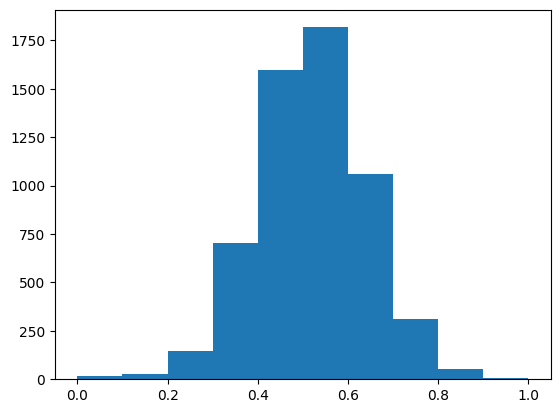

In [24]:
plt.hist(components[0])

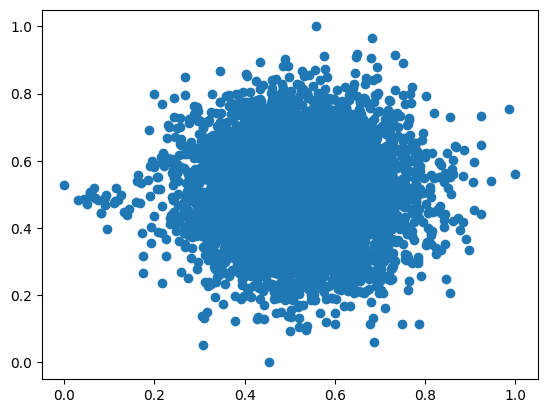

In [25]:
plt.plot(*components[[0,1]], 'o')

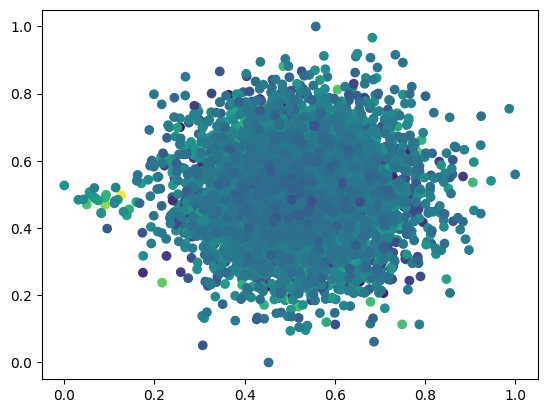

In [26]:
plt.scatter(*components[[0,1]], c = np.log10(subhalos['SubhaloMass']))

In [27]:
subhalos['SubhaloLenType'][:,1]

array([46136876,  6297959,  1420531, ...,     5159,     3954,     4680],
      dtype=int32)

/var/folders/0r/_1bnthz146q2xj0c42f4nl_80000gq/T/ipykernel_69196/465684355.py:1: RuntimeWarning: divide by zero encountered in log10
  plt.scatter(*components[[0,1]], c = np.log10(subhalos['SubhaloLenType'][:,0]))


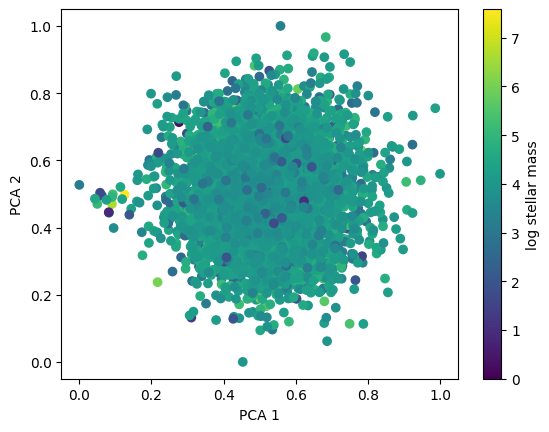

In [28]:
plt.scatter(*components[[0,1]], c = np.log10(subhalos['SubhaloLenType'][:,0]))
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.colorbar(label="log stellar mass")

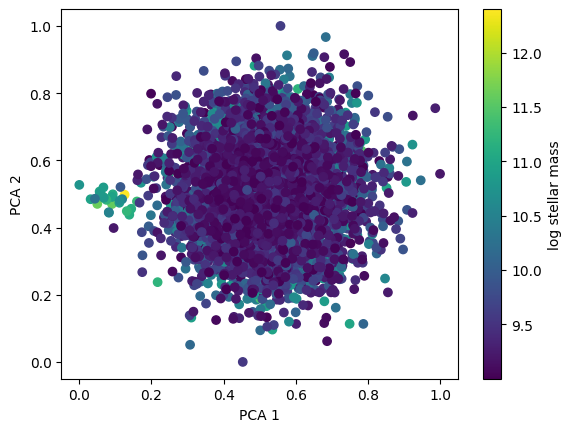

In [29]:
plt.scatter(*components[[0,1]], c = np.log10(subhalos['SubhaloMassType'][:,4] * 1e10))
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.colorbar(label="log stellar mass")

In [30]:
subhalos.keys()

dict_keys(['count', 'SubhaloFlag', 'SubhaloMass', 'SubhaloMassType', 'SubhaloParent', 'SubhaloPos', 'SubhaloLenType', 'SubhaloStarMetallicity', 'SubhaloSFR', 'SubhaloGasMetallicity', 'SubhaloGasMetalFractions'])

In [31]:
subhalos['SubhaloStarMetallicity']

array([0.02862233, 0.02126505, 0.02540692, ..., 0.01047968, 0.01409606,
       0.01055776], dtype=float32)

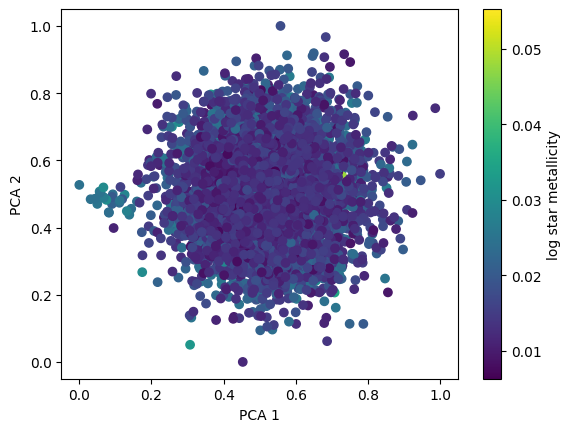

In [40]:
plt.scatter(*components[[0,1]], c = subhalos['SubhaloStarMetallicity'])
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.colorbar(label="log star metallicity")

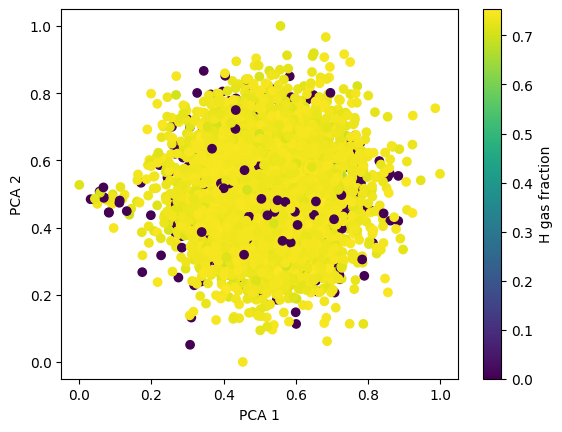

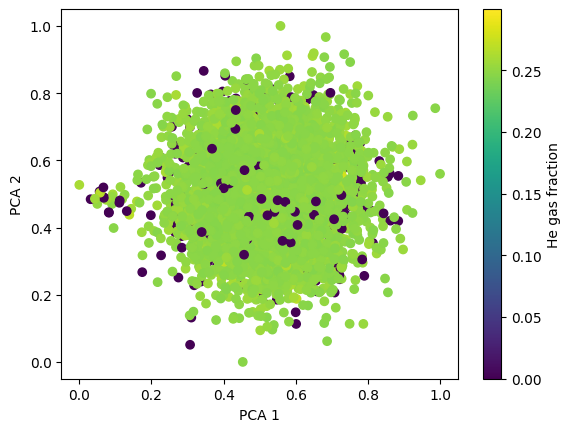

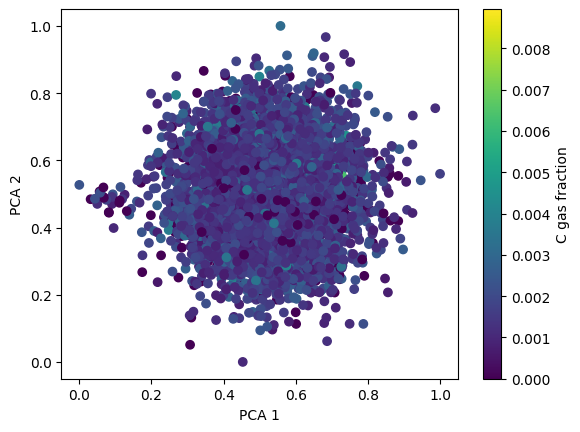

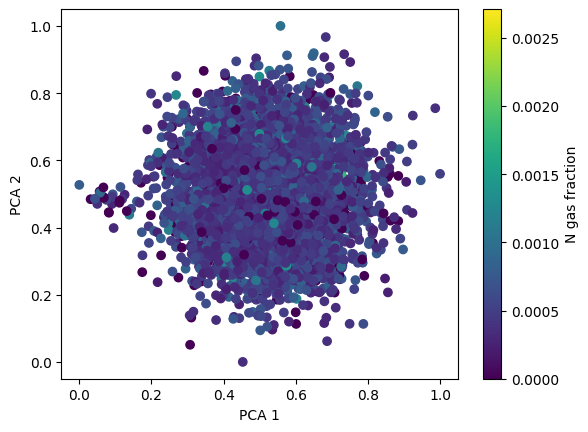

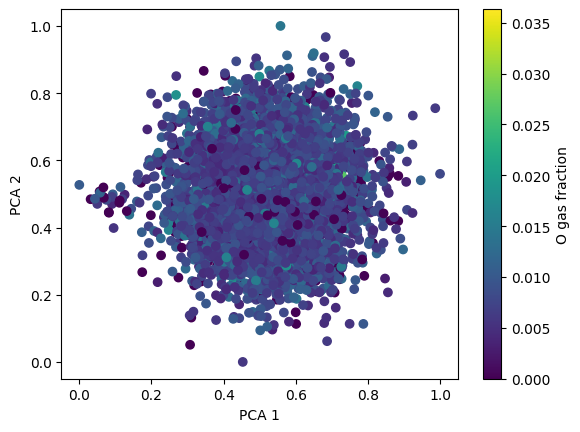

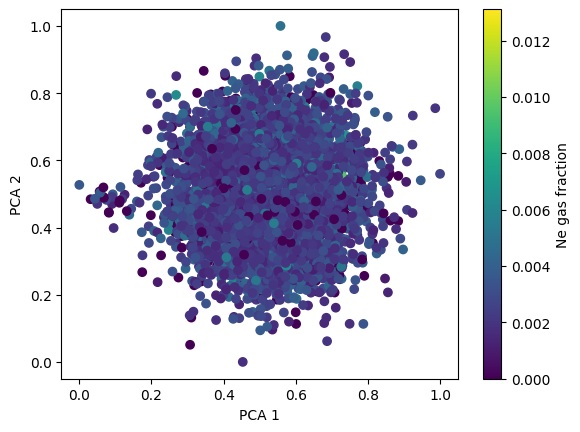

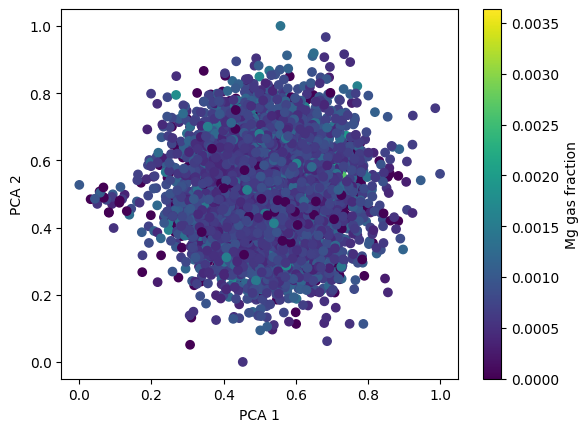

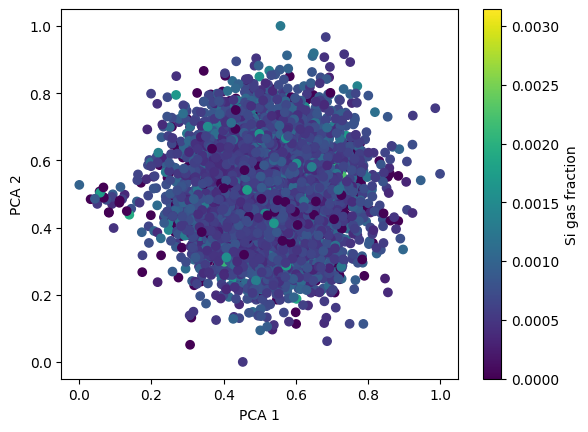

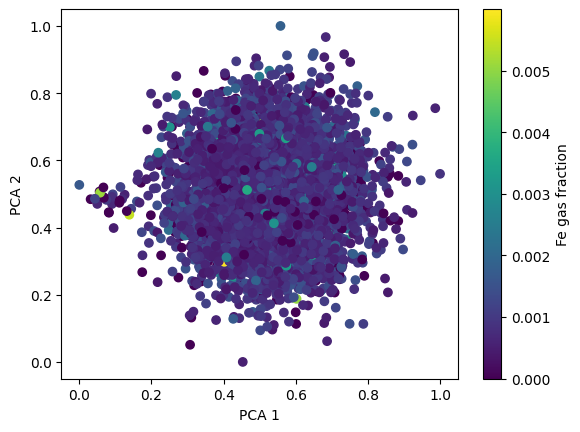

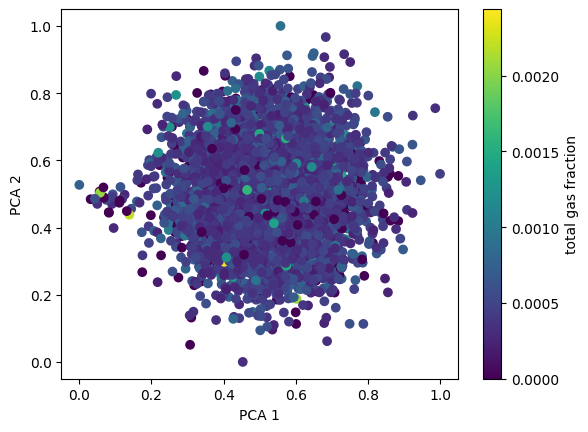

In [33]:
gases = ['H', 'He', 'C', 'N', 'O', 'Ne', 'Mg', 'Si', 'Fe', 'total']
for i in range(10):
    fig, ax = plt.subplots()
    s = ax.scatter(*components[[0,1]], c = subhalos['SubhaloGasMetalFractions'][:,i])
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    cbar = fig.colorbar(s, label=gases[i]+" gas fraction")
    plt.show()

/var/folders/0r/_1bnthz146q2xj0c42f4nl_80000gq/T/ipykernel_69196/4242542965.py:1: RuntimeWarning: divide by zero encountered in log10
  plt.scatter(*components[[0,1]], c = np.log10(subhalos['SubhaloGasMetallicity']))


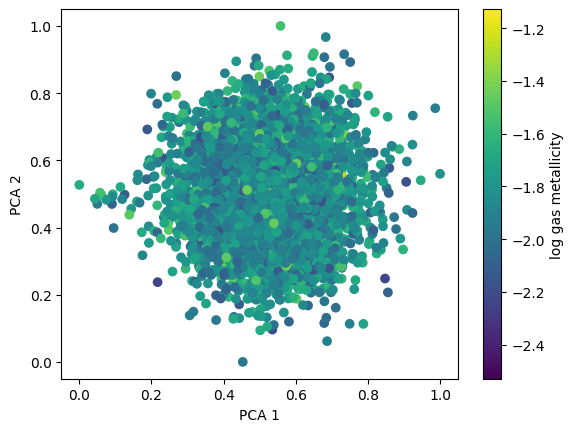

In [34]:
plt.scatter(*components[[0,1]], c = np.log10(subhalos['SubhaloGasMetallicity']))
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.colorbar(label="log gas metallicity")

/var/folders/0r/_1bnthz146q2xj0c42f4nl_80000gq/T/ipykernel_69196/3560304120.py:1: RuntimeWarning: divide by zero encountered in log10
  plt.scatter(*components[[0,1]], c = np.log10(subhalos['SubhaloSFR']))


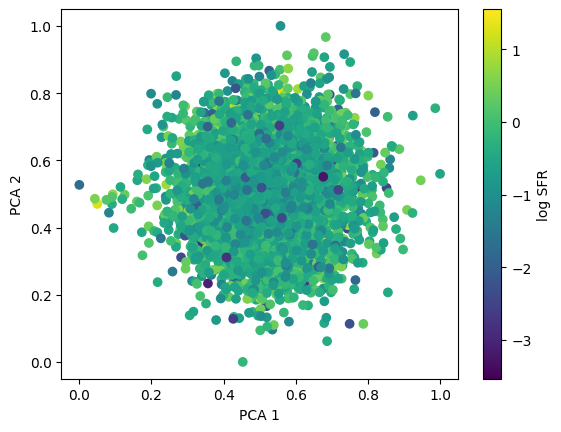

In [35]:
plt.scatter(*components[[0,1]], c = np.log10(subhalos['SubhaloSFR']))
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.colorbar(label="log SFR")

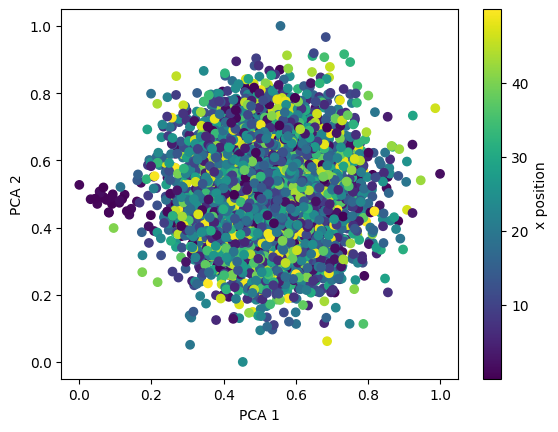

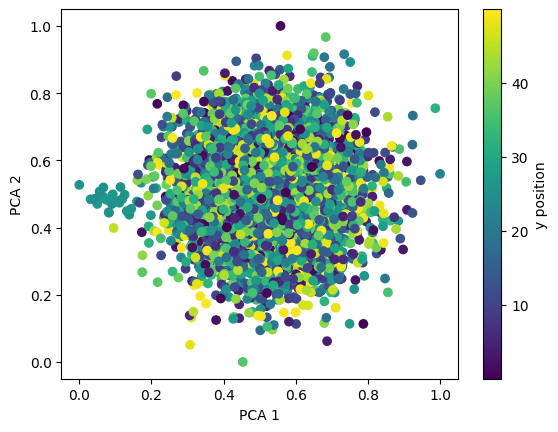

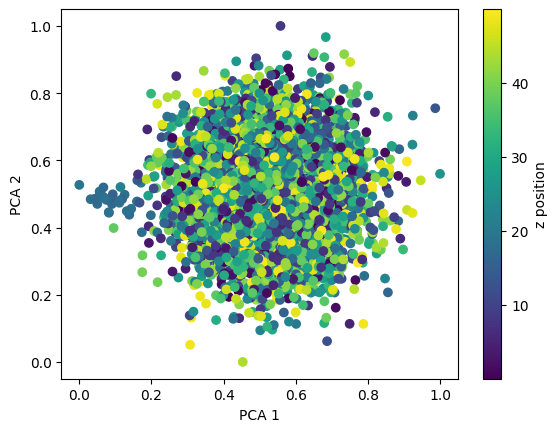

In [36]:
l = ["x", "y", "z"]
for i in range(3):
    plt.scatter(*components[[0,1]], c = subhalos['SubhaloPos'][:,i])
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.colorbar(label=l[i]+" position")
    plt.show()

In [39]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.offline import plot
# df = px.data.iris()
fig = px.scatter_3d(x=subhalos['SubhaloPos'][:,0], y=subhalos['SubhaloPos'][:,1], z=subhalos['SubhaloPos'][:,2],
                    color=np.clip(components[0], 0.2, 1))
fig.update_layout(margin=dict(l=0, r=0, b=0, t=0))
plot(fig, filename='galaxies.html', auto_open=True)


'galaxies.html'

distance to the boundary

plot positions and color by altent representation

weights by inverse square of distance

In [589]:
G = nx.Graph()
G.add_nodes_from(np.arange(subhalos['count']))

In [590]:
# ebunch = [(i[0], i[1], {'weight':i[2]}) for i in edge_list[::2]]
ebunch = [(i[0], i[1], i[2]) for i in edge_list[::2]]
G.add_weighted_edges_from(ebunch)

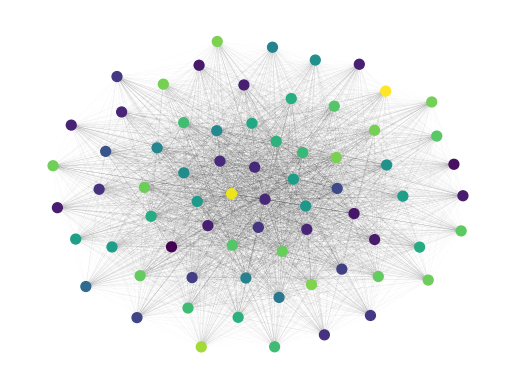

In [592]:
fig, ax = plt.subplots()
num_nodes = 70
subgraph = G.subgraph(np.arange(num_nodes))
nx.draw(subgraph, node_size=50, ax = ax, width = list(nx.get_edge_attributes(subgraph, "weight").values()), node_color = components[0][:num_nodes])

In [593]:
cmap = mpl.colormaps['Spectral']

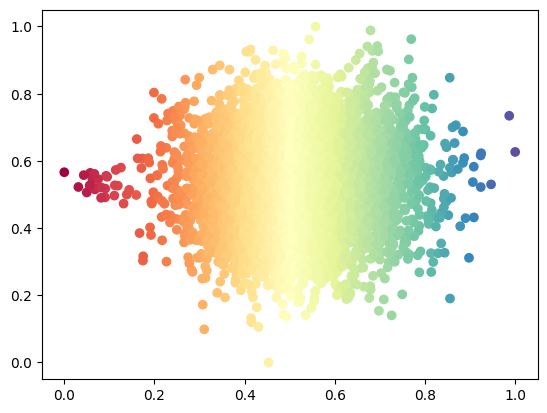

In [594]:
f = plt.scatter(components[0], components[1], c =components[0], cmap=cmap)

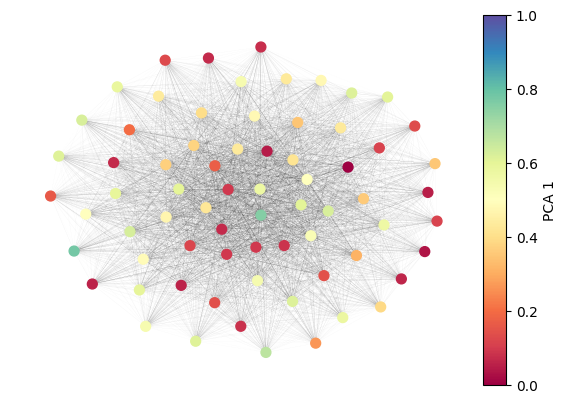

In [595]:
fig,ax = plt.subplots()
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='5%', pad=0.05)
nx.draw(subgraph, pos = nx.spring_layout(subgraph), node_size=50, ax = ax, width = list(nx.get_edge_attributes(subgraph, "weight").values()), node_color = cmap(components[0][:num_nodes]))
cbar = plt.colorbar(f, cax=cax)
cbar.set_label("PCA 1")
plt.show()

In [352]:
# filename = "snap_099.0.hdf5"
# with h5py.File(filename, "r") as f:
#     # Print all root level object names (aka keys) 
#     # these can be group or dataset names 
#     print("Keys: %s" % f.keys())
#     # get first object name/key; may or may NOT be a group
#     a_group_key = list(f.keys())[0]
#     for key in f.keys():
#         print(key)
#         print(list(f[key]))
    
#     print(type(f[a_group_key])) 
